In [1]:
from pathlib import Path
import os

# Move notebook execution to repo root
os.chdir(Path.cwd().parent)

ROOT = Path.cwd()

print(ROOT)

/Users/prathiksharamesh/single-cell-lung-atlas-covid19


In [3]:
import scanpy as sc 
adata= sc.read_csv('data/raw/GSE171524_RAW/GSM5226574_C51ctr_raw_counts.csv').T

In [4]:
#Removing genes which are present in less than 10 cells 

sc.pp.filter_genes(adata, min_cells=10)

In [5]:
# To retain top 2000 highly variable genes 
sc.pp.highly_variable_genes(adata,n_top_genes=2000,flavor='seurat_v3',subset=True)

In [6]:
# model training 
import scvi 
scvi.model.SCVI.setup_anndata(adata)
vae = scvi.model.SCVI(adata) 
vae.train() 

/opt/miniconda3/envs/lungatlas/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/opt/miniconda3/envs/lungatlas/lib/python3.11/site-packages/scvi/train/_trainrunner.py:98: UserWarning: `accelerator` has been automatically set to `cpu` although 'mps' exists. If you wish to run on mps backend, use explicitly accelerator='mps' in train function.In future releases it will become default for mps supported machines.
  accelerator, lightning_devices, device = parse_device_args(
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
/opt/miniconda3/envs/lungatlas/lib/python3.11/site-packages/lightning/pytorch/trainer/setup.py:175: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
💡 Tip: For seamless cloud logging and experiment tracking, try installing [lit

Epoch 400/400: 100%|██████████| 400/400 [05:18<00:00,  1.19it/s, v_num=1, train_loss=323]

`Trainer.fit` stopped: `max_epochs=400` reached.


Epoch 400/400: 100%|██████████| 400/400 [05:18<00:00,  1.26it/s, v_num=1, train_loss=323]


In [7]:
solo = scvi.external.SOLO.from_scvi_model(vae)
solo.train() 

INFO     Creating doublets, preparing SOLO model.                                                                  


/opt/miniconda3/envs/lungatlas/lib/python3.11/site-packages/scvi/train/_trainrunner.py:98: UserWarning: `accelerator` has been automatically set to `cpu` although 'mps' exists. If you wish to run on mps backend, use explicitly accelerator='mps' in train function.In future releases it will become default for mps supported machines.
  accelerator, lightning_devices, device = parse_device_args(
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
/opt/miniconda3/envs/lungatlas/lib/python3.11/site-packages/lightning/pytorch/trainer/setup.py:175: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/opt/miniconda3/envs/lungatlas/lib/python3.11/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstanc

Epoch 195/400:  49%|████▉     | 195/400 [00:28<00:29,  6.94it/s, v_num=1, train_loss_step=0.374, train_loss_epoch=0.299]
Monitored metric validation_loss did not improve in the last 30 records. Best score: 0.284. Signaling Trainer to stop.


In [8]:
#prediction 
df = solo.predict()
df['prediction'] = solo.predict(soft = False)
df

/opt/miniconda3/envs/lungatlas/lib/python3.11/site-packages/torch/utils/_contextlib.py:124: UserWarning: Prior to scvi-tools 1.1.3, `SOLO.predict` with `soft=True` (the default option) returned logits instead of probabilities. This behavior has since been corrected to return probabilities. The previous behavior can be replicated by passing in `return_logits=True`.
  return func(*args, **kwargs)
/opt/miniconda3/envs/lungatlas/lib/python3.11/site-packages/torch/utils/_contextlib.py:124: UserWarning: Prior to scvi-tools 1.1.3, `SOLO.predict` with `soft=True` (the default option) returned logits instead of probabilities. This behavior has since been corrected to return probabilities. The previous behavior can be replicated by passing in `return_logits=True`.
  return func(*args, **kwargs)


,doublet,singlet,prediction
TAGGTACCATGGCCAC-1_1,0.782280,0.217720,doublet
ATTCACTGTAACAGGC-1_1,0.894695,0.105305,doublet
TAACTTCCAACCACGC-1_1,0.743679,0.256321,doublet
TTGGGTACACGACAAG-1_1,0.838063,0.161937,doublet
AGGCCACAGAGTCACG-1_1,0.735650,0.264350,doublet
...,...,...,...
CGCCATTGTTTGCCGG-1_1,0.576315,0.423685,doublet
CACTGGGGTCTACGTA-1_1,0.000955,0.999045,singlet
CATACTTGTAGAGGAA-1_1,0.005308,0.994693,singlet
TTTGGTTTCCACGGAC-1_1,0.002129,0.997871,singlet


In [9]:
df.groupby('prediction').count()

,doublet,singlet
prediction,,
doublet,1404,1404
singlet,4695,4695


In [10]:
df['dif'] = df.doublet - df.singlet
df

,doublet,singlet,prediction,dif
TAGGTACCATGGCCAC-1_1,0.782280,0.217720,doublet,0.564560
ATTCACTGTAACAGGC-1_1,0.894695,0.105305,doublet,0.789391
TAACTTCCAACCACGC-1_1,0.743679,0.256321,doublet,0.487358
TTGGGTACACGACAAG-1_1,0.838063,0.161937,doublet,0.676127
AGGCCACAGAGTCACG-1_1,0.735650,0.264350,doublet,0.471300
...,...,...,...,...
CGCCATTGTTTGCCGG-1_1,0.576315,0.423685,doublet,0.152630
CACTGGGGTCTACGTA-1_1,0.000955,0.999045,singlet,-0.998091
CATACTTGTAGAGGAA-1_1,0.005308,0.994693,singlet,-0.989385
TTTGGTTTCCACGGAC-1_1,0.002129,0.997871,singlet,-0.995741


In [11]:
import seaborn as sns

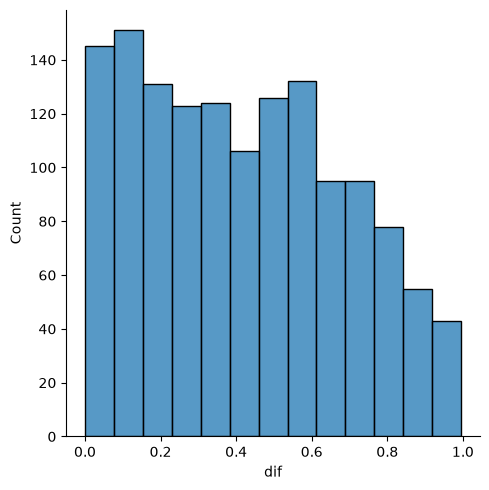

In [12]:
sns.displot(df[df.prediction == 'doublet'], x = 'dif')

In [13]:
doublets = df[(df.prediction == 'doublet') & (df.dif > 0.6)]
doublets

,doublet,singlet,prediction,dif
ATTCACTGTAACAGGC-1_1,0.894695,0.105305,doublet,0.789391
TTGGGTACACGACAAG-1_1,0.838063,0.161937,doublet,0.676127
ACTGATGTCTGCACCT-1_1,0.962285,0.037715,doublet,0.924569
CCACGAGTCTCTTAAC-1_1,0.959448,0.040552,doublet,0.918897
ACTTCCGCACAACGCC-1_1,0.943069,0.056931,doublet,0.886138
...,...,...,...,...
TGGGATTGTTCAGTAC-1_1,0.801833,0.198167,doublet,0.603666
AGTTCGATCAGGGATG-1_1,0.850760,0.149241,doublet,0.701519
TGAGACTCAGGACTAG-1_1,0.894533,0.105467,doublet,0.789067
TCAGCAAAGCAACTTC-1_1,0.811249,0.188751,doublet,0.622498


In [ ]:
import scanpy as sc 
adata= sc.read_csv('data/raw/GSE171524_RAW/GSM5226574_C51ctr_raw_counts.csv').T

In [16]:
adata.obs['doublet'] = adata.obs.index.isin(doublets.index)

In [17]:
adata = adata[~adata.obs.doublet]

In [18]:
adata.write('data/processed/GSM5226574_C51ctr_raw_counts_doublet_removed.h5ad',compression='lzf') 